Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Elementos finitos en 2D

Queremos resolver la ecuación de Poisson

$$- \nabla^2 u = f(\mathbf{x})\quad \forall \mathbf{x}\in \Omega \, ,$$

con

$$u(\mathbf{x}) = 0\quad \forall \mathbf{x} \in \partial\Omega\, .$$


Vamos a usar una solución aproximada de la forma

$$u(\mathbf{x}) = \sum_{n=0}^{N} u_n \phi_n(\mathbf{x})\, .$$

Si usamos el método de Galerkin, la ecuación diferencial es equivalente
al siguiente problema variacional

$$\int\limits_\Omega (\nabla u) \cdot (\nabla \phi_n) d\Omega
= \int\limits_\Omega  \phi_n f d\Omega\, \quad \forall \phi_n\, .$$

Si remplazamos $u(x)$ en este sistema obtenemos

$$\sum_{j=0}^N \left[\int\limits_\Omega (\nabla \phi_i) \cdot (\nabla \phi_j) d\Omega\right] u_j
= \int\limits_\Omega  \phi_j f d\Omega\, \quad \forall \phi_j\, .$$

Esto lleva al siguiente sistema de ecuaciones

$$[K]\{\mathbf{u}\} = \{\mathbf{b}\}$$

Usando triángulos lineales, las matrices de rigidez son

$$K_\text{local} =  \frac{|J|}{2} (J^{-1}D)^T (J^{-1}D)\, ,$$

y

$$b_\text{local} = \frac{|J| f(\mathbf{x}_m)}{6} 
\begin{bmatrix}1\\ 1\\ 1 \end{bmatrix}\, ,$$

donde $|J|$ es el determinante jacobiano de la transformación y
$\mathbf{x}_m$ es el centroide del triángulo. Acá asumismos que
el término fuente era constante en el elemento.

<div class="alert alert-warning">

Acá estamos dejando por fuera muchos detalles del ensamblaje de la
matriz y del mapeo del ordenamiento local al global.
</div>

In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import meshio

In [4]:
# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [5]:
def assem(coords, elems, source):
    """
    Ensambla la matriz de rigidez y el vector de cargas
    
    Parámetros
    ----------
    coords : ndarray, float
        Coordenadas de los nodos.
    elems : ndarray, int
        Conectividad de los elementos.
    source : ndarray, float
        Término fuente evaluado en los nodos de la malla.
    
    Retorna
    -------
    stiff : ndarray, float
        Matriz de rigidez del problema.
    rhs : ndarray, float
        Vector de cargas del problema.
    """
    ncoords = coords.shape[0]
    stiff = np.zeros((ncoords, ncoords))
    rhs = np.zeros((ncoords))
    for el_cont, elem in enumerate(elems):
        stiff_loc, det = local_stiff(coords[elem])
        rhs[elem] += det*np.mean(source[elem])/6
        for row in range(3):
            for col in range(3):
                row_glob, col_glob = elem[row], elem[col]
                stiff[row_glob, col_glob] += stiff_loc[row, col]
    return stiff, rhs

In [6]:
def local_stiff(coords):
    """Calcula la matriz de rigidez local
        
    Parámetros
    ----------
    coords : ndarray, float
        Coordenadas de los nodos del elemento.
    
    Retorna
    -------
    stiff : ndarray, float
        Matriz de rigidez local.
    det : float
        Determinante del jacobian.
    """
    dNdr = np.array([
            [-1, 1, 0],
            [-1, 0, 1]])
    jaco = dNdr @ coords
    det = np.linalg.det(jaco)
    jaco_inv = np.linalg.inv(jaco)
    dNdx = jaco_inv @ dNdr
    stiff = 0.5 * det * (dNdx.T @ dNdx)
    return stiff, det

In [7]:
def pts_restringidos(coords, malla, lineas_rest):
    """
    Identifica los nodos restringidos y libres
    para la malla.
        
    Parámetros
    ----------
    coords : ndarray, float
        Coordenadas de los nodos del elemento.
    malla : Meshio mesh
        Objeto de malla de Meshio.
    lineas_rest : list
        Lista con los números para las líneas
        restringidas.
    
    Retorna
    -------
    pts_rest : list
        Lista de puntos restringidos.
    pts_libres : list
        Lista de puntos libres.
    """
    lineas = [malla.cells[k].data for k in lineas_rest]
    pts_rest = []
    for linea in lineas:
        pts_rest += set(linea.flatten())
    pts_libres = list(set(range(coords.shape[0])) - set(pts_rest))
    return pts_rest, pts_libres

## Ejemplo

Vamos a resolver el problema en una malla de 6 triángulos que forman un
hexágono regular para ilustrar el uso de las funciones.

In [8]:
sq3 = np.sqrt(3)
coords = np.array([
        [sq3, -1],
        [0, 0],
        [2*sq3, 0],
        [0, 2],
        [2*sq3, 2],
        [sq3, 3],
        [sq3, 1]])
elems = np.array([
        [1, 0, 6],
        [0, 2, 6],
        [2, 4, 6],
        [4, 5, 6],
        [5, 3, 6],
        [3, 1, 6]])

A continuación visualizamos la malla.

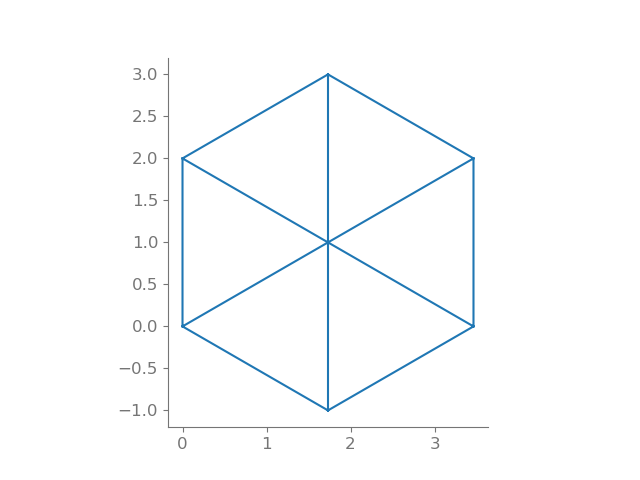

In [9]:
plt.figure()
plt.triplot(coords[:, 0], coords[:, 1])
plt.axis("image")
plt.show()

En la siguiente celda definimos el problema.

In [10]:
source = np.ones(7)
stiff, rhs = assem(coords, elems, source)
free = range(6)
sol = np.linalg.solve(stiff[np.ix_(free, free)], rhs[free])
sol_c = np.zeros(coords.shape[0])
sol_c[free] = sol

Y visualizamos el resultado.

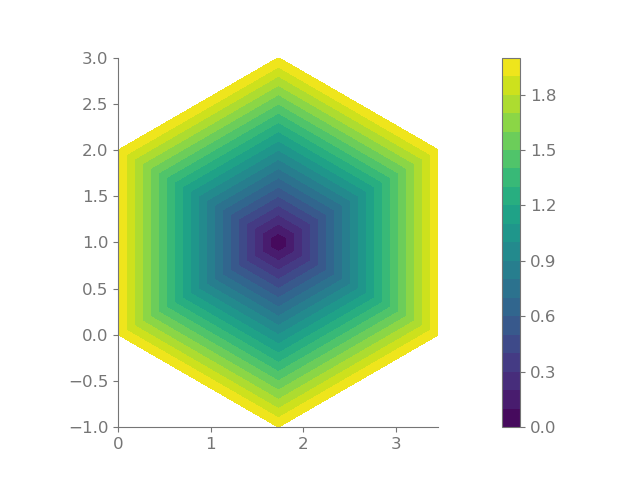

In [11]:
plt.figure()
plt.tricontourf(coords[:, 0], coords[:, 1], sol_c, 20)
plt.colorbar()
plt.axis("image")
plt.show()

## Un ejemplo más elaborado

En este caso leemos una malla de Gmsh usando ``meshio``.

In [12]:
malla = meshio.read("cuadrado101.msh")

Para este ejemplo los triángulos están en la
posición ``4`` de las celdas de la malla.

In [13]:
pts = malla.points
x, y = pts[:, 0:2].T
tri = malla.cells[4].data

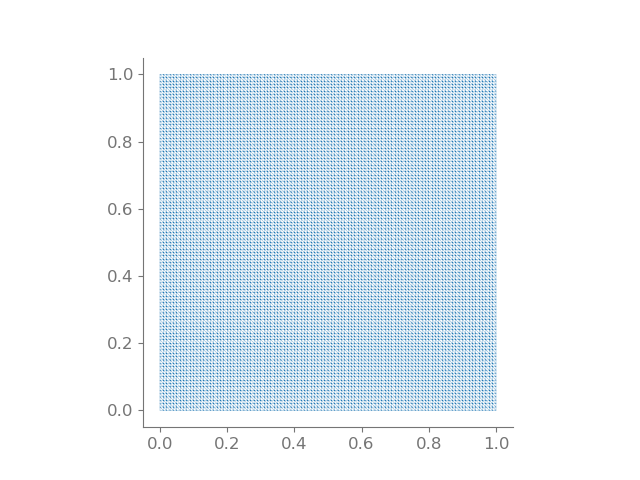

In [14]:
plt.figure()
plt.triplot(x, y, tri, linewidth=0.2)
plt.axis("image")
plt.show()

In [15]:
fuente = 8*np.pi**2 * np.sin(2*np.pi*x) * np.sin(2*np.pi*y)
stiff, rhs = assem(pts[:, :2], tri, fuente)

Tenemos una función que nos permite identificar los nodos
que están restringidos y los que están libres.

In [16]:
pts_rest, pts_libres = pts_restringidos(pts, malla, [0, 1, 2, 3])

Y resolvemos.

In [17]:
sol = np.linalg.solve(stiff[np.ix_(pts_libres, pts_libres)], rhs[pts_libres])
sol_c = np.zeros(pts.shape[0])
sol_c[pts_libres] = sol

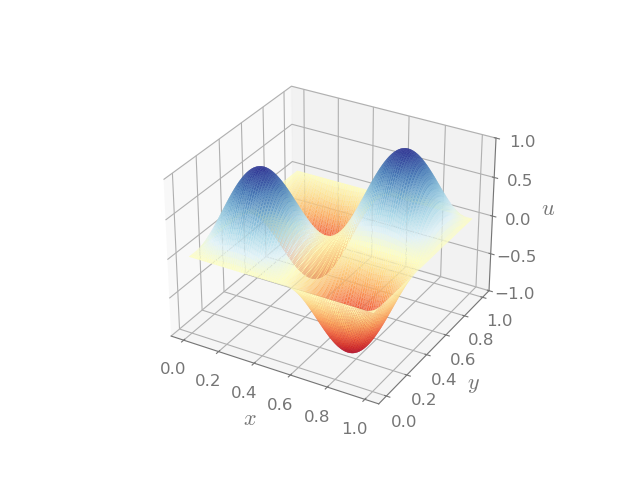

In [18]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_trisurf(x, y, sol_c, triangles=tri, cmap="RdYlBu")
ax.set_zlim(-1, 1)
ax.set_xlabel(r"$x$", fontsize=16)
ax.set_ylabel(r"$y$", fontsize=16)
ax.set_zlabel(r"$u$", fontsize=16)
plt.show()